## Task B.3

In [2]:
import numpy as np
import torch

if torch.cuda.is_available():
    print("GPU is available:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")

GPU is available: Tesla T4


In [1]:
!python setup.py build_ext --inplace

Compiling cmandelbrot.pyx because it changed.
[1/1] Cythonizing cmandelbrot.pyx
running build_ext
building 'cmandelbrot' extension
creating build/temp.linux-x86_64-cpython-312
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/numpy/_core/include -I/usr/include/python3.12 -c cmandelbrot.c -o build/temp.linux-x86_64-cpython-312/cmandelbrot.o
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from cmandelbrot.c:1249:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy AP

In [3]:
import timeit
def benchmark(f, width, height, x_min, x_max, y_min, y_max):
  timer = timeit.Timer(lambda: f(width, height, x_min, x_max, y_min, y_max))
  ts = timer.repeat(repeat=10, number=1)
  return np.mean(ts)

[2026-02-26 15:48:50.313453] Beanchmarking: (256, 144)
[2026-02-26 15:48:52.827366] Beanchmarking: (426, 240)
[2026-02-26 15:48:59.057246] Beanchmarking: (640, 360)
[2026-02-26 15:49:11.908030] Beanchmarking: (853, 480)
[2026-02-26 15:49:34.756606] Beanchmarking: (1280, 720)
[2026-02-26 15:50:26.486596] Beanchmarking: (1920, 1080)
[2026-02-26 15:52:26.284227] Beanchmarking: (2560, 1440)
[2026-02-26 15:55:56.346638] done!


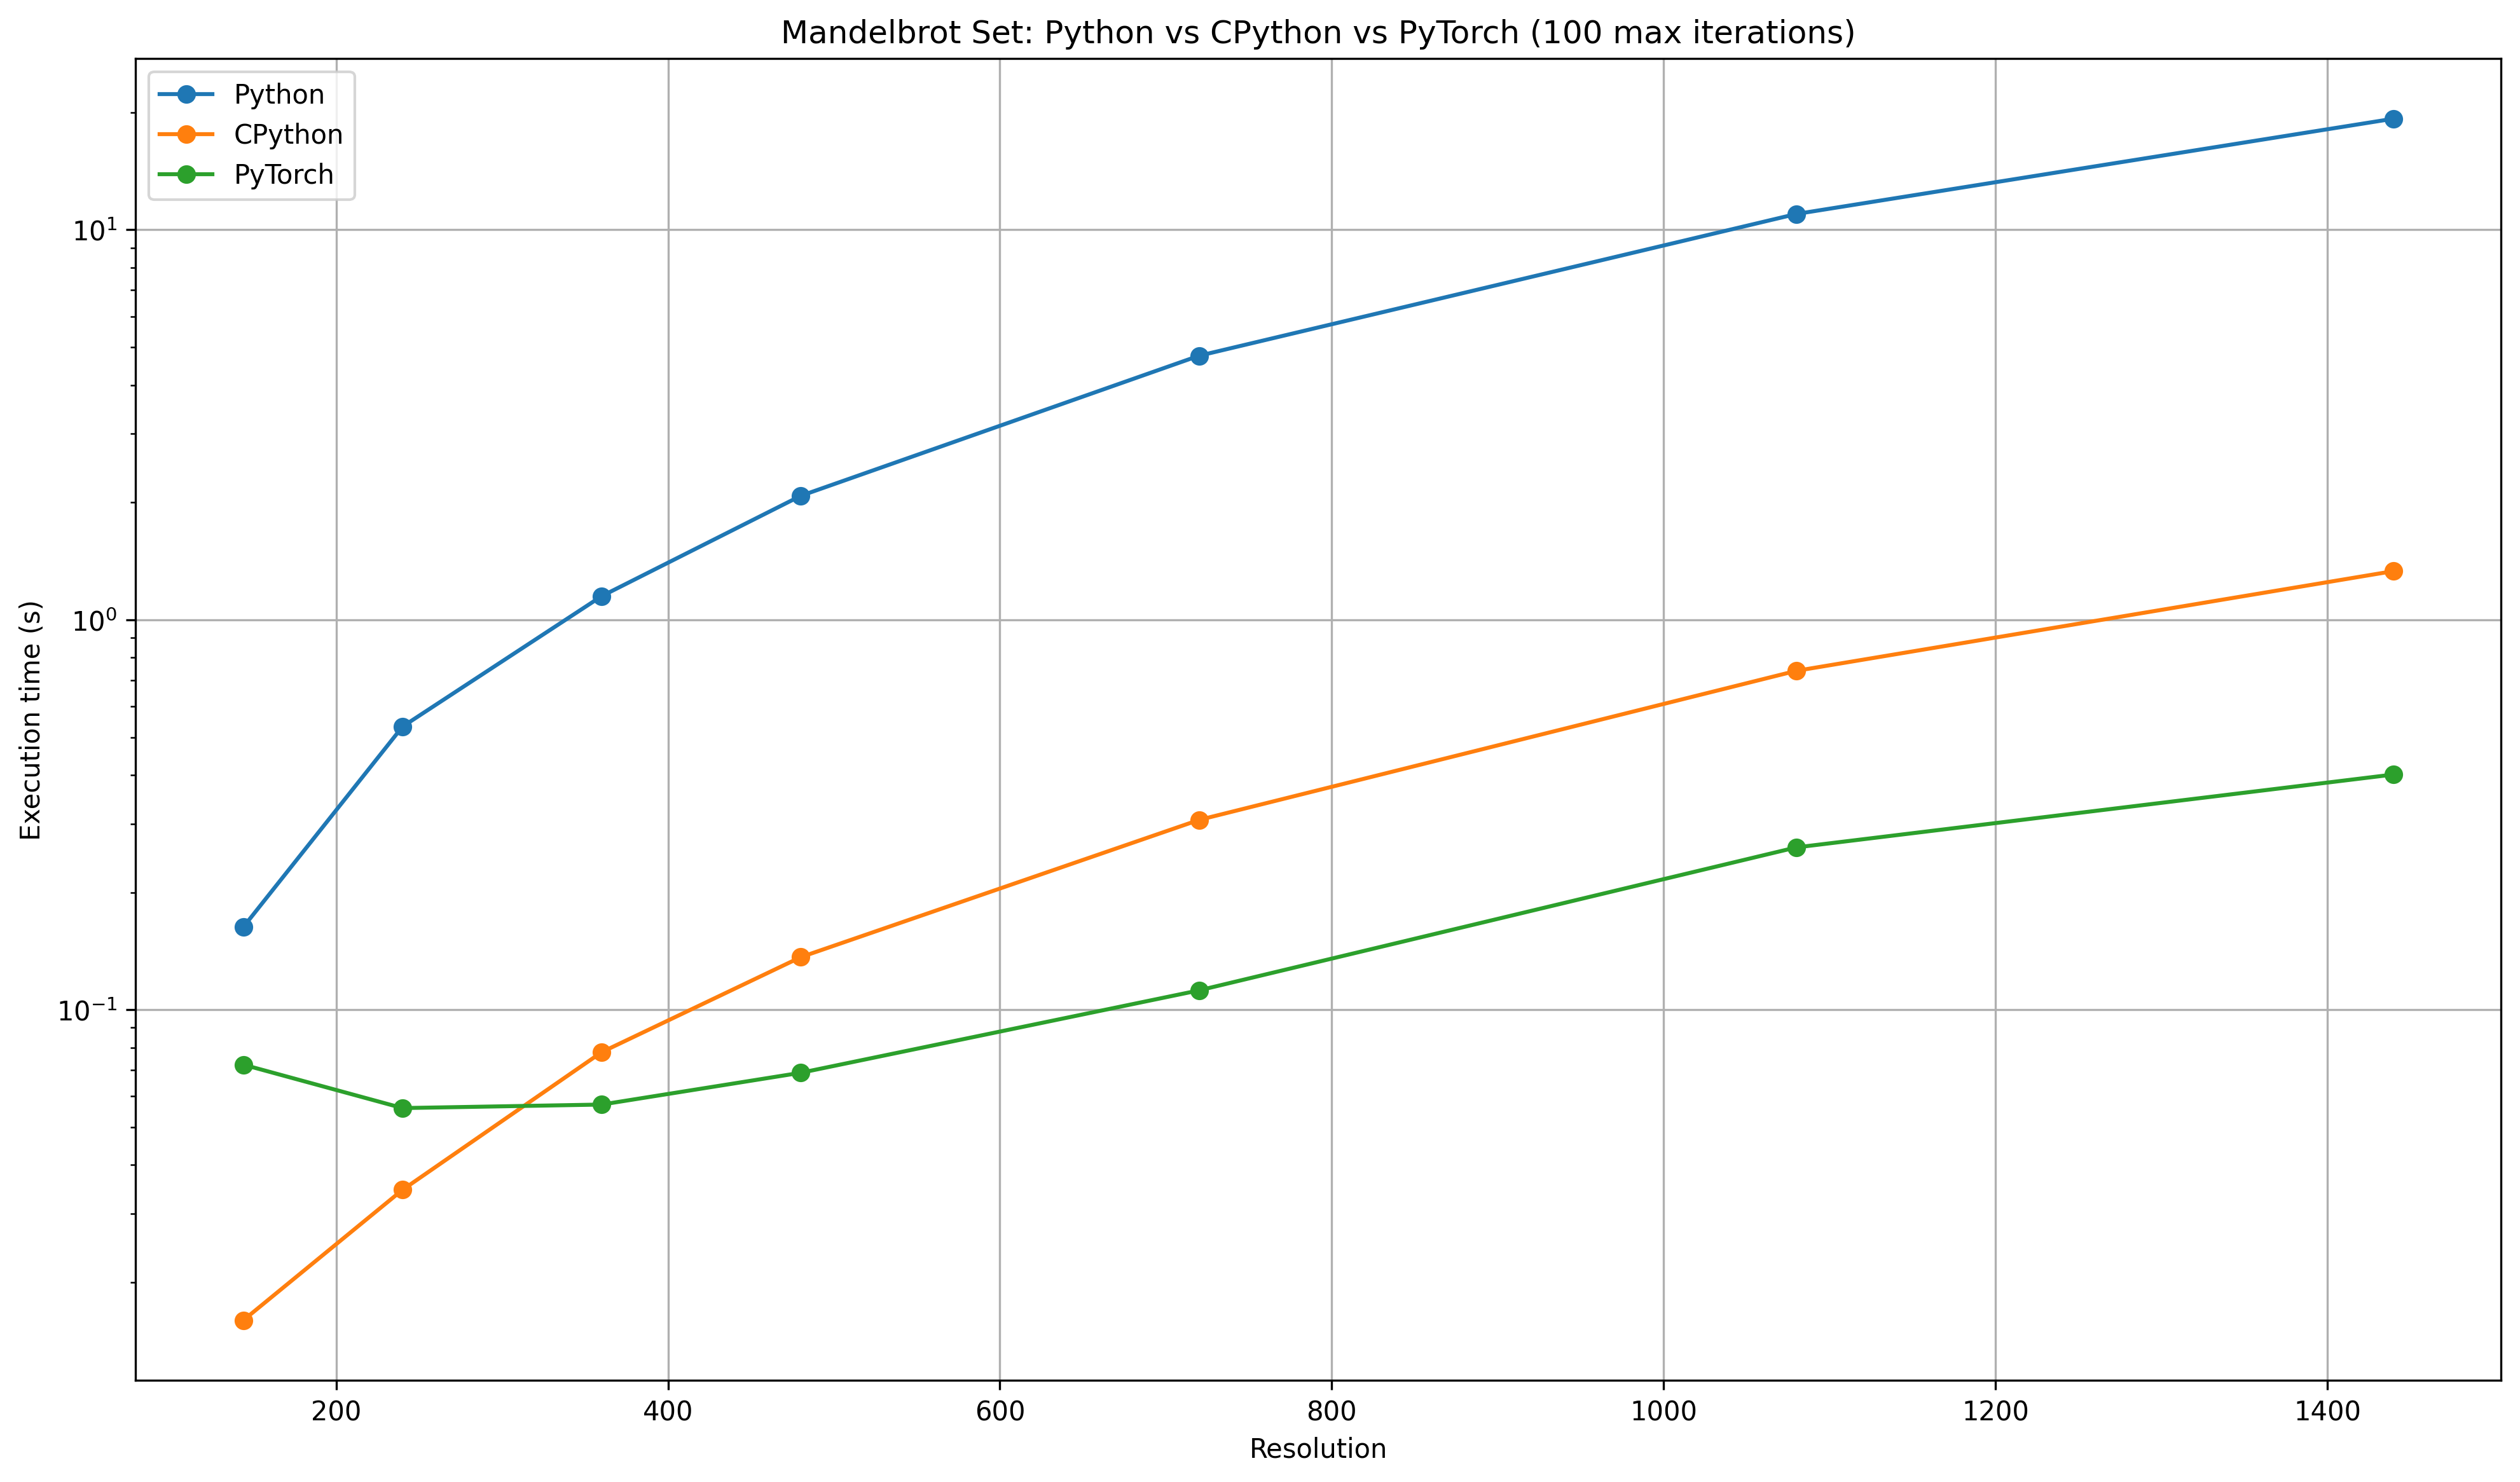

In [12]:
import matplotlib.pyplot as plt
from datetime import datetime

from og_mandelbrot import mandelbrot_set as og_set
from mandelbrot import mandelbrot_set as c_set
from tmandelbrot import tmandelbrot_set as t_set

x_min, x_max, y_min, y_max = -2, 1, -1, 1
height = [144, 240, 360, 480, 720, 1080, 1440]
resolutions = [(int(h * 16 / 9), h) for h in height]
og, c, t = [],[],[]

for r in resolutions:
  print(f"[{datetime.now()}]","Beanchmarking:", r)
  og.append(benchmark(og_set, r[0], r[1], x_min, x_max, y_min, y_max))
  c.append(benchmark(c_set, r[0], r[1], x_min, x_max, y_min, y_max))
  t.append(benchmark(t_set, r[0], r[1], x_min, x_max, y_min, y_max))
print(f"[{datetime.now()}]","done!")

plt.figure(figsize=(16, 9), dpi=300)
plt.plot(height, og, marker='o', label="Python")
plt.plot(height, c, marker='o', label="CPython")
plt.plot(height, t, marker='o', label="PyTorch")

plt.legend()
plt.yscale("log")
plt.xlabel("Resolution")
plt.ylabel("Execution time (s)")
plt.title("Mandelbrot Set: Python vs CPython vs PyTorch (100 max iterations)")
plt.grid(True)
plt.show()

As can bee seen the pure Python implemnation losses overall which is to be expected. PyTorch was the fastest with CPython following behind, what's intresting is that at smaller gridsizes CPython preformed better than PyTorch. This is likely to the buss limitations and the time it takes to get the data to the GPU exceeeding the actual computation time.